# 01 · Point Verification — 2-m Temperature Forecast vs Station Observations

**Runnable companion to [`python-verification-guide.md`](../python-verification-guide.md).**

This notebook verifies a real deterministic temperature forecast against real
hourly surface observations, end to end:

1. Download an **archived NWP forecast** (Open-Meteo Historical-Forecast API) and
   **station observations** (Iowa Environmental Mesonet ASOS).
2. Match forecast to observations on valid time.
3. Compute continuous metrics (ME, MAE, RMSE, *r*) with bootstrap confidence
   intervals, and stratify the bias by hour of day.
4. Plot the time series, a forecast-vs-observed scatter, and the diurnal bias.

**Station:** Jakarta – Soekarno-Hatta (ICAO `WIII`), 10–20 Jan 2024.

> Data is fetched live and cached under `meteo_examples/data/`. If you are
> offline, the committed cache is used automatically, so this notebook is fully
> reproducible. See [`../../NOTEBOOKS.md`](../../NOTEBOOKS.md) for setup.

In [1]:
# Setup. If `import meteo_examples` fails, run `pip install -e .` from the repo root.
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from meteo_examples import dataio, verif

STATION = "WIII"          # Jakarta Soekarno-Hatta
LAT, LON = -6.13, 106.65
START, END = "2024-01-10", "2024-01-20"
plt.rcParams["figure.dpi"] = 110

## 1 · Download forecast and observations

In [2]:
# Archived deterministic forecast (best available global model at this point)
fcst = dataio.open_meteo_forecast(
    LAT, LON, START, END,
    hourly="temperature_2m,wind_speed_10m,wind_direction_10m",
).rename(columns={"time": "valid"})

# Hourly ASOS observations; tmpc is 2-m temperature in degC
obs = dataio.iem_asos(STATION, START, END)
print(f"forecast steps: {len(fcst)}   |   obs reports: {len(obs)}")
fcst.head(3)

forecast steps: 264   |   obs reports: 481


,valid,temperature_2m,wind_speed_10m,wind_direction_10m
0,2024-01-10 00:00:00,25.5,4.2,250
1,2024-01-10 01:00:00,28.1,6.7,234
2,2024-01-10 02:00:00,29.7,7.7,221


## 2 · Match forecast to observations

ASOS reports are sub-hourly and irregular; the forecast is hourly. We floor the
observation timestamps to the hour, keep one report per hour, then inner-join on
valid time so every pair is a genuine like-for-like comparison.

In [3]:
o = obs.dropna(subset=["tmpc"]).copy()
o["valid"] = o["valid"].dt.floor("h")
o = o.groupby("valid", as_index=False).first()

matched = pd.merge(fcst, o, on="valid", how="inner")
print(f"matched pairs: {len(matched)}")
matched[["valid", "temperature_2m", "tmpc"]].head()

matched pairs: 239


,valid,temperature_2m,tmpc
0,2024-01-10 00:00:00,25.5,27.0
1,2024-01-10 01:00:00,28.1,29.0
2,2024-01-10 02:00:00,29.7,30.0
3,2024-01-10 03:00:00,31.0,31.0
4,2024-01-10 04:00:00,31.6,32.0


## 3 · Continuous verification metrics

In [4]:
stats = verif.continuous_metrics(matched["temperature_2m"], matched["tmpc"])
pd.DataFrame([stats]).round(3)

,N,ME,MAE,RMSE,r,Mult_Bias,Skill_Score,FBAR,OBAR
0,239,-0.692,1.047,1.367,0.862,0.975,0.62,26.873,27.565


**Reading the numbers:** `ME` is the mean error (forecast − obs), so a
negative value is a cool bias. `RMSE` is the typical error magnitude, and `r` is
the correlation. `Skill_Score` is the MSE skill relative to simply predicting the
observed mean (1 = perfect, 0 = no better than climatology).

In [5]:
# Bootstrap 95% confidence intervals for RMSE and bias (ME)
def boot(fc, ob, fn, n=2000, seed=0):
    rng = np.random.default_rng(seed)
    fc, ob = np.asarray(fc, float), np.asarray(ob, float)
    vals = [fn(*(lambda i: (fc[i], ob[i]))(rng.integers(0, len(fc), len(fc)))) for _ in range(n)]
    return fn(fc, ob), np.percentile(vals, 2.5), np.percentile(vals, 97.5)

rmse = lambda f, o: np.sqrt(np.mean((f - o) ** 2))
me   = lambda f, o: np.mean(f - o)
for name, fn in [("RMSE", rmse), ("ME", me)]:
    est, lo, hi = boot(matched["temperature_2m"], matched["tmpc"], fn)
    print(f"{name:5s} = {est:+.2f} °C   95% CI [{lo:+.2f}, {hi:+.2f}]")

RMSE  = +1.37 °C   95% CI [+1.20, +1.53]
ME    = -0.69 °C   95% CI [-0.85, -0.55]


## 4 · Time series: forecast vs observed

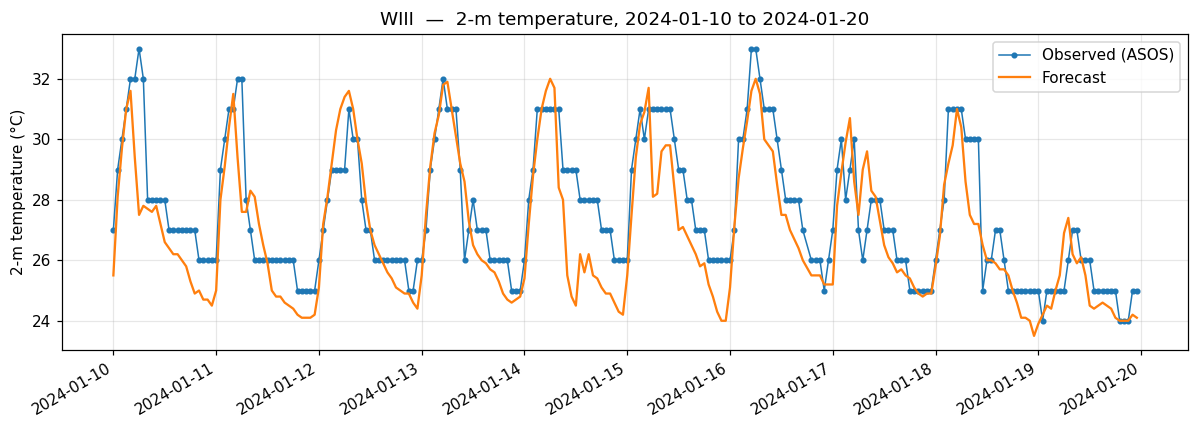

In [6]:
fig, ax = plt.subplots(figsize=(11, 4))
ax.plot(matched["valid"], matched["tmpc"], "o-", ms=3, lw=1, label="Observed (ASOS)")
ax.plot(matched["valid"], matched["temperature_2m"], "-", lw=1.5, label="Forecast")
ax.set_ylabel("2-m temperature (°C)")
ax.set_title(f"{STATION}  —  2-m temperature, {START} to {END}")
ax.legend(); ax.grid(alpha=0.3)
fig.autofmt_xdate(); plt.tight_layout()

## 5 · Scatter: forecast vs observed

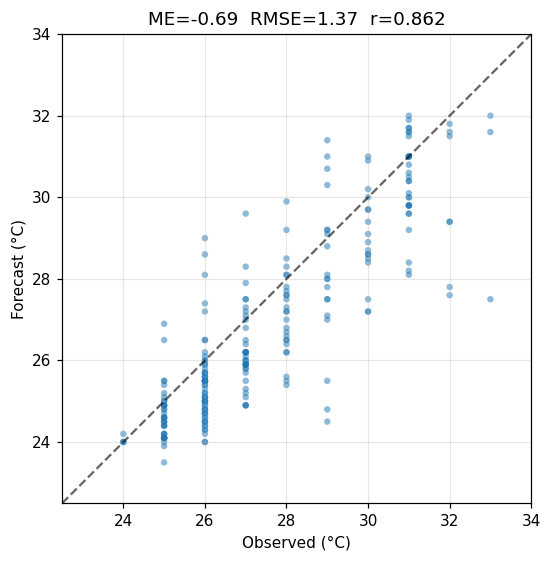

In [7]:
fig, ax = plt.subplots(figsize=(5.2, 5.2))
ax.scatter(matched["tmpc"], matched["temperature_2m"], s=18, alpha=0.5, edgecolors="none")
lims = [matched[["tmpc", "temperature_2m"]].min().min() - 1,
        matched[["tmpc", "temperature_2m"]].max().max() + 1]
ax.plot(lims, lims, "k--", alpha=0.6)
ax.set(xlim=lims, ylim=lims, xlabel="Observed (°C)", ylabel="Forecast (°C)",
       title=f"ME={stats['ME']:+.2f}  RMSE={stats['RMSE']:.2f}  r={stats['r']:.3f}")
ax.set_aspect("equal"); ax.grid(alpha=0.3); plt.tight_layout()

## 6 · Stratify the bias by hour of day

A single RMSE hides *when* the model errs. Grouping the error by hour of day
(a `pandas` groupby) often reveals a diurnal signature — e.g. too-cool
afternoons or a warm nocturnal bias.

,mean,std,count
hour,,,
0,-0.90,0.49,10
1,-0.46,0.70,10
2,-0.42,0.57,10
3,-0.25,0.96,10
4,0.22,0.88,10
5,-0.44,1.51,10
6,-0.77,2.68,10
7,-0.36,2.06,10
8,-0.46,1.66,10


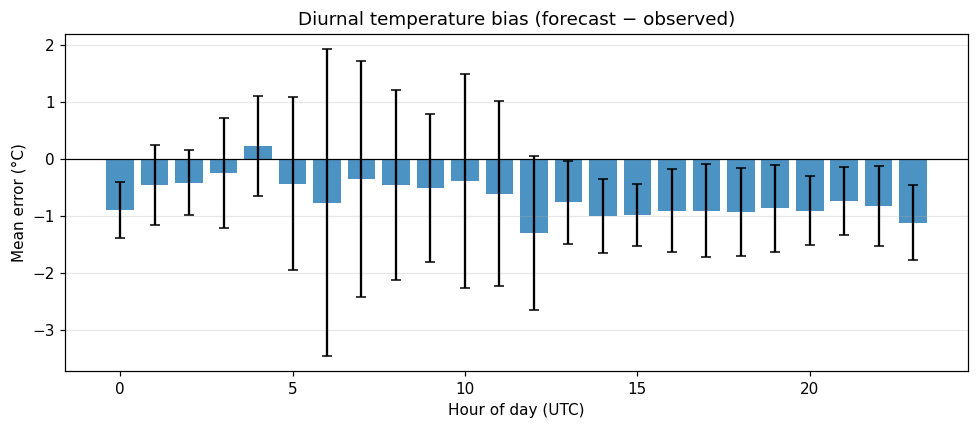

In [8]:
m = matched.copy()
m["err"] = m["temperature_2m"] - m["tmpc"]
m["hour"] = m["valid"].dt.hour
by_hour = m.groupby("hour")["err"].agg(["mean", "std", "count"])

fig, ax = plt.subplots(figsize=(9, 4))
ax.bar(by_hour.index, by_hour["mean"], yerr=by_hour["std"], capsize=3, alpha=0.8)
ax.axhline(0, color="k", lw=0.8)
ax.set(xlabel="Hour of day (UTC)", ylabel="Mean error (°C)",
       title="Diurnal temperature bias (forecast − observed)")
ax.grid(alpha=0.3, axis="y"); plt.tight_layout()
by_hour.round(2)

## 7 · Bonus: wind speed and direction

Wind needs **both** speed and direction. Direction is circular, so we use the
circular MAE from `verif` rather than a naive difference.

In [9]:
ow = obs.dropna(subset=["sknt", "drct"]).copy()
ow["valid"] = ow["valid"].dt.floor("h")
ow = ow.groupby("valid", as_index=False).first()
ow["wspd_obs"] = ow["sknt"] * 0.514444          # knots -> m/s
mw = pd.merge(fcst, ow, on="valid", how="inner")

spd = verif.continuous_metrics(mw["wind_speed_10m"], mw["wspd_obs"])
dir_mae = verif.wind_direction_mae(mw["wind_direction_10m"], mw["drct"])
print(f"10-m wind speed : ME={spd['ME']:+.2f}  RMSE={spd['RMSE']:.2f} m/s  (N={spd['N']})")
print(f"10-m wind dir   : circular MAE = {dir_mae:.1f}°")

10-m wind speed : ME=+7.37  RMSE=8.06 m/s  (N=238)
10-m wind dir   : circular MAE = 23.9°


---

### What to try next
- Swap `STATION`, `LAT/LON`, and the dates to verify a location you care about
  (use the right IEM `network=` code — e.g. `"WA_ASOS"` for a Washington station).
- Aggregate **partial sums** across many stations/days with
  `verif.partial_sums()` + `verif.aggregate_partial_sums()` instead of averaging
  RMSE (see the guide's *Aggregation Pitfall* section).
- Continue to [`02_categorical_precip.ipynb`](02_categorical_precip.ipynb) for
  precipitation verification.